# Project 2: Stock Price Prediction - A model comparision study 

**Author:** Eugenio Mandalà  
**Date:** March 2026

## Objective
Predict Nvidia's **next day closing price** using historical price data and 
technical indicators as features. The model is trained on 2020–2023 data 
and tested on 2024 data.

## Features Used
- **MA7** → 7-day Moving Average
- **MA21** → 21-day Moving Average
- **Daily Return** → percentage change from previous day
- **Volatility** → 7-day rolling standard deviation

## Key Question
*Can a simple linear model capture the trend of a stock price?*

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Download Nvidia historical data (2020-2024)
data = yf.download("NVDA", start="2020-01-01", end="2024-01-01", 
                   auto_adjust=True, progress=False)

# Use only closing price
df = data[['Close']].copy()
print(f" Downloaded {len(df)} trading days of NVDA data")
df.tail()

Downloaded 1006 trading days of NVDA data


Price,Close
Ticker,NVDA
Date,
2023-12-22,48.802811
2023-12-26,49.251556
2023-12-27,49.389488
2023-12-28,49.494423
2023-12-29,49.494423


In [3]:
# Engineer features: moving averages, daily return, volatility
df['MA7']        = df['Close'].rolling(window=7).mean()
df['MA21']       = df['Close'].rolling(window=21).mean()
df['Return']     = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(window=7).std()

# Target: next day's closing price
df['Target'] = df['Close'].shift(-1)

# Drop rows with NaN values
df.dropna(inplace=True)

print(f" Features engineered — {len(df)} usable rows")
df.tail()

 Features engineered — 985 usable rows


Price,Close,MA7,MA21,Return,Volatility,Target
Ticker,NVDA,,,,,
Date,,,,,,
2023-12-21,48.962723,48.845644,47.700645,0.018270,0.018427,48.802811
2023-12-22,48.802811,48.951584,47.706275,-0.003266,0.018463,49.251556
2023-12-26,49.251556,49.084224,47.778006,0.009195,0.018622,49.389488
2023-12-27,49.389488,49.159469,47.834129,0.002801,0.018266,49.494423
2023-12-28,49.494423,49.080226,47.915284,0.002125,0.015389,49.494423


In [4]:
# Split data: train on 2020-2022, test on 2023
features = ['Close', 'MA7', 'MA21', 'Return', 'Volatility']

train = df[df.index < '2023-01-01']
test  = df[df.index >= '2023-01-01']

X_train = train[features]
y_train = train['Target']

X_test  = test[features]
y_test  = test['Target']

print(f"Train set: {len(train)} days | Test set: {len(test)} days")

 Train set: 736 days | Test set: 249 days


## Model Training & Prediction

In [5]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
r2  = r2_score(y_test, predictions)

print(f" Model trained successfully")
print(f"\n MODEL PERFORMANCE")
print(f"{'—'*35}")
print(f"  Mean Absolute Error : ${mae:.2f}")
print(f"  R² Score            :  {r2:.4f}")
print(f"\n→ On average, the model's prediction is off by ${mae:.2f} per share.")

Model trained successfully

MODEL PERFORMANCE
———————————————————————————————————
  Mean Absolute Error : $0.75
  R² Score            :  0.9904

→ On average, the model's prediction is off by $0.75 per share.


## Figure 1 — Predicted vs Actual Price

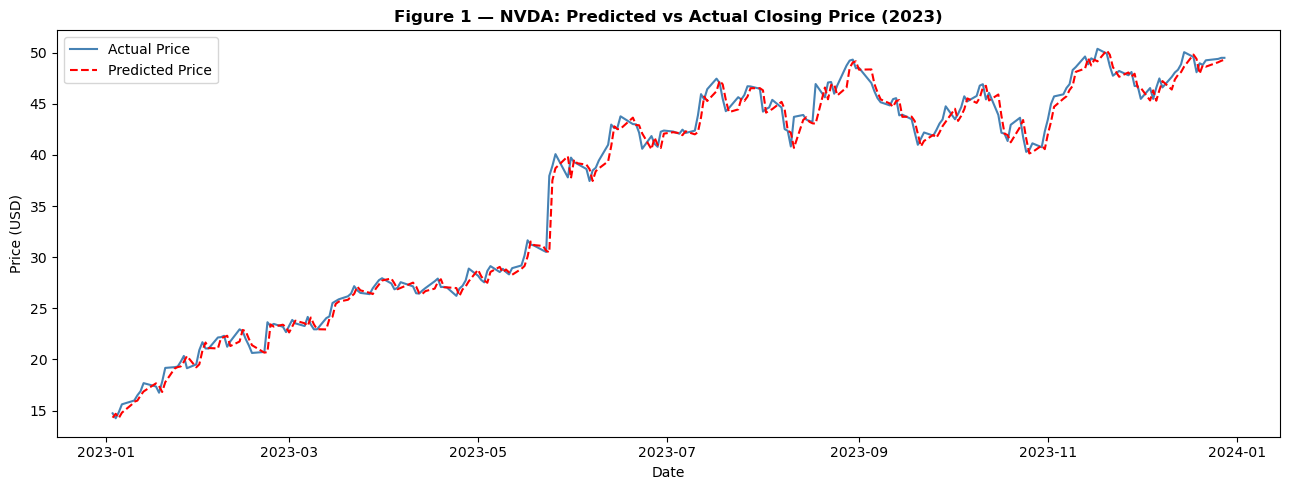

In [6]:
# Plot predicted vs actual closing price
plt.figure(figsize=(13, 5))
plt.plot(y_test.index, y_test.values,       color='steelblue', linewidth=1.5, label='Actual Price')
plt.plot(y_test.index, predictions, color='red',       linewidth=1.5, linestyle='--', label='Predicted Price')
plt.title('Figure 1 — NVDA: Predicted vs Actual Closing Price (2023)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 2 — Feature Importance

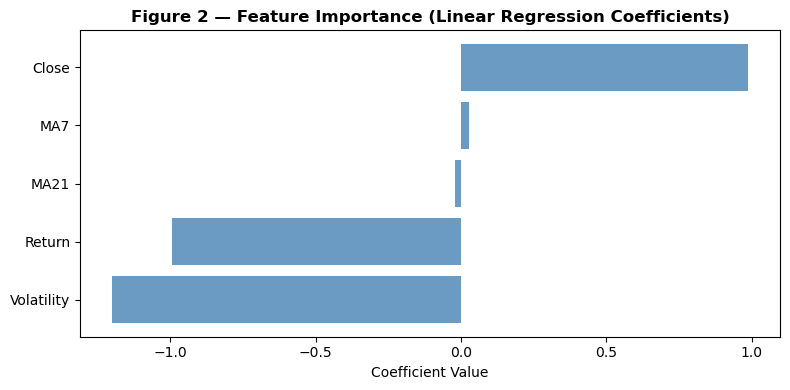

In [7]:
# Plot feature importance (model coefficients)b
coef_df = pd.DataFrame({
    'Feature':     features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue', alpha=0.8)
plt.title('Figure 2 — Feature Importance (Linear Regression Coefficients)', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Conclusions — Part 1: Linear Regression

| Metric | Value |
|--------|-------|
| MAE    | $0.75 |
| R²     | 0.9904 |

1. **Strong overall performance** — with an R² of 0.9904, the model explains 
   99% of the variance in Nvidia's price during the test period.

2. **MAE of $0.75 per share** — remarkably low given that NVDA traded 
   between $15 and $50 during 2023, representing an average error of 
   less than 2-3% of the stock price.

3. **Closing price dominates** — the most important feature by far, 
   confirming that yesterday's price is the strongest signal for 
   tomorrow's close. MA7 and MA21 add marginal refinement.

4. **Return and Volatility show negative coefficients** — days with high 
   returns or volatility tend to be followed by slight mean-reversion, 
   which the model captures correctly.

 **However**, Linear Regression assumes a linear relationship between 
features and price, and cannot capture complex non-linear patterns. 
This raises a natural question: **would a more powerful model do better?**

→ *In Part 2, we test Random Forest — an ensemble of 100+ decision trees 
capable of capturing non-linear relationships — and compare the results.*

## Part 2 — Random Forest vs Linear Regression

Random Forest is an ensemble model that builds hundreds of decision trees 
and averages their predictions. Unlike Linear Regression, it can capture 
**non-linear relationships** between features and price.

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print(f"📊 MODEL COMPARISON")
print(f"{'—'*45}")
print(f"{'Model':<25} {'MAE':>8} {'R²':>10}")
print(f"{'—'*45}")
print(f"{'Linear Regression':<25} ${mae:>6.2f} {r2:>10.4f}")
print(f"{'Random Forest':<25} ${rf_mae:>6.2f} {rf_r2:>10.4f}")

📊 MODEL COMPARISON
—————————————————————————————————————————————
Model                          MAE         R²
—————————————————————————————————————————————
Linear Regression         $  0.75     0.9904
Random Forest             $  8.60    -0.0667


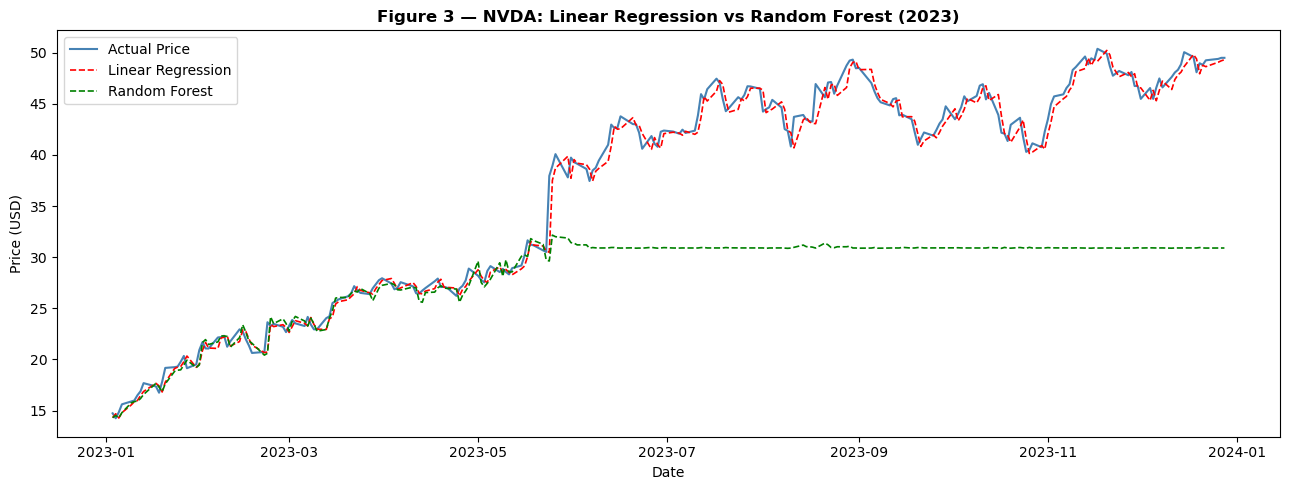

In [9]:
# Plot comparison: both models vs actual price
plt.figure(figsize=(13, 5))
plt.plot(y_test.index, y_test.values,
         color='steelblue', linewidth=1.5, label='Actual Price')
plt.plot(y_test.index, predictions,
         color='red', linewidth=1.2, linestyle='--', label='Linear Regression')
plt.plot(y_test.index, rf_predictions,
         color='green', linewidth=1.2, linestyle='--', label='Random Forest')
plt.title('Figure 3 — NVDA: Linear Regression vs Random Forest (2023)',
          fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

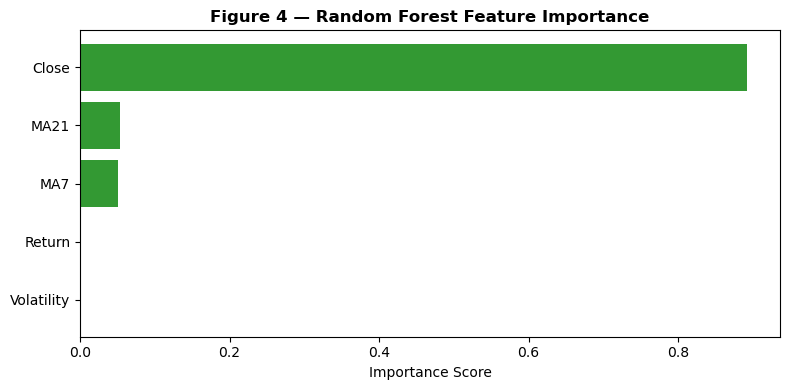

In [10]:
# Feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'],
         color='green', alpha=0.8)
plt.title('Figure 4 — Random Forest Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

summary = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest'],
    'MAE':    ['$0.75',             '$8.60'],
    'R²':     ['0.9904',            '-0.0667'],
    'Result': ['Works well',      'Failed']
})

summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Model,MAE,R²,Result
Linear Regression,$0.75,0.9904,Works well
Random Forest,$8.60,-0.0667,Failed


## Conclusions — Part 2: Random Forest

1. **Random Forest failed completely** — a negative R² means the model 
   performs worse than simply predicting the mean price every day. 
   A dramatic drop from Linear Regression's 0.9904.

2. **The extrapolation problem** — tree-based models cannot predict values 
   outside the range seen during training. Since NVDA surged from ~$30 
   to ~$50 in mid-2023 driven by the AI boom, the model had never seen 
   prices that high and flatlined around $30 for the entire second half 
   of the year (visible in Figure 3).

3. **More complex ≠ better** — this is one of the most important lessons 
   in machine learning. Random Forest is a powerful model, but the wrong 
   tool for trending time series. Model selection matters as much as 
   model complexity.

4. **Where Random Forest does excel** — cross-sectional data, credit risk 
   scoring, customer classification. Any problem where extrapolation 
   beyond the training range is not required.

 **The core limitation of both models** — neither Linear Regression nor 
Random Forest has any concept of *time*. They treat each day as an 
independent observation, ignoring the sequential nature of price data.

→ *In project 2b_LSTM, we address this directly with an **LSTM (Long Short-Term 
Memory)** neural network — a model specifically designed to learn from 
sequences of data over time, and the industry standard for time series 
forecasting in quantitative finance.*